In [1]:
import yfinance as yf
import pandas as pd

In [2]:
# DataFetcher class to retrieve stock data
# This class takes a stock ticker, start date, and end date as input and uses the yfinance library to fetch historical stock data.
# The fetch_data method downloads the data and returns it as a DataFrame.
# Example usage:
# data_fetcher = DataFetcher('AAPL', '2020-01-01', '2021-01-01')

class DataFetcher:
    def __init__(self, ticker, start_date, end_date):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date

    def fetch_data(self):
        data = yf.download(self.ticker, start=self.start_date, end=self.end_date)
        return data

In [3]:
# Get user input for stock ticker and date range
ticker = input("Enter the stock ticker (e.g., AAPL): ")
start_date = input("Enter the start date (YYYY-MM-DD): ")
end_date = input("Enter the end date (YYYY-MM-DD): ")
stock_data = DataFetcher(ticker, start_date, end_date).fetch_data()
print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open    Volume
Ticker          NFLX      NFLX      NFLX      NFLX      NFLX
Date                                                        
2003-01-02  0.081786  0.090000  0.081071  0.084643  83972000
2003-01-03  0.077286  0.085000  0.077143  0.085000  32480000
2003-01-06  0.079286  0.080000  0.076214  0.078571  30030000
2003-01-07  0.078357  0.079571  0.077143  0.077143  19376000
2003-01-08  0.081500  0.085714  0.076214  0.077143  53564000


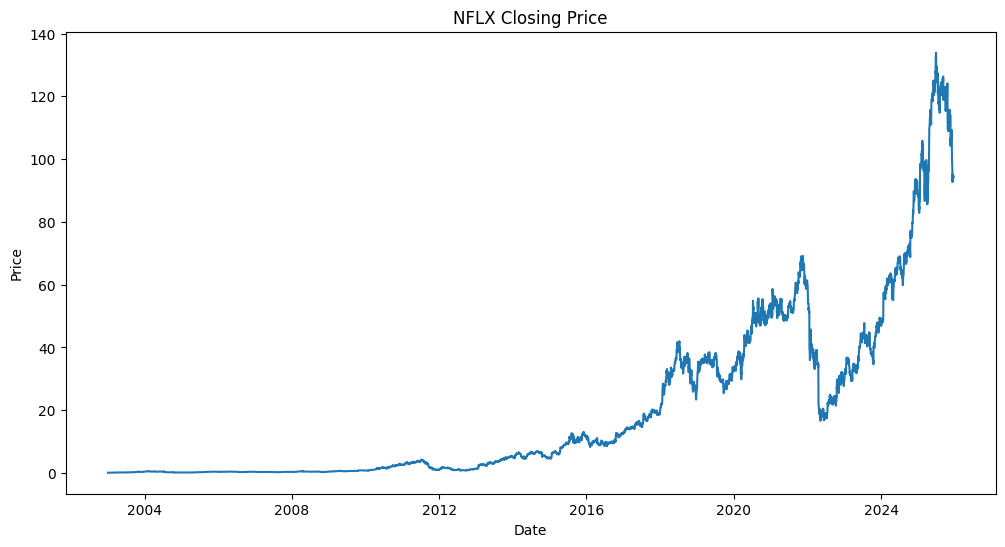

In [4]:
# Visualize the closing price
# This code uses the matplotlib library to create a line plot of the closing price of the stock over time. The x-axis represents the date, and the y-axis represents the closing price. The plot is displayed using plt.show().
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'])
plt.title(f'{ticker} Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import numpy as np

In [6]:
# Set device for PyTorch
# This code checks if a GPU is available and sets the device accordingly. If a GPU is available, it will use 'cuda'; otherwise, it will fall back to 'cpu'. This allows the code to take advantage of GPU acceleration if possible.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [7]:
# Preprocess the data
# This code uses the StandardScaler from scikit-learn to normalize the closing price data. Normalization is a common preprocessing step in machine learning that helps improve the performance of models by scaling the features to a standard range. The fit_transform method is used to fit the scaler to the data and then transform it in one step.
# Note: In a real implementation, you would typically want to fit the scaler on the training data and then transform both the training and test data separately to avoid data leakage. Here, for simplicity, we are applying it directly to the entire dataset.
scaler = StandardScaler()
stock_data['Close'] = scaler.fit_transform(stock_data['Close'])

# Create sequences for LSTM
# This code creates sequences of closing price data to be used as input for an LSTM model. The seq_length variable defines the length of each sequence (in this case, 60 time steps). The loop iterates through the stock data and appends sequences of closing prices to the data list. Each sequence consists of seq_length closing prices followed by the next closing price, which will be used as the target for prediction.

seq_length = 60
data = []

# Loop through the stock data and create sequences of closing prices

for i in range(len(stock_data) - seq_length):
    data.append(stock_data['Close'].values[i:i+seq_length])

# Convert the list of sequences to a NumPy array for easier manipulation and to be compatible with PyTorch tensors.

data = np.array(data)

In [8]:
# Split the data into training and testing sets
# This code splits the data into training and testing sets. The train_size variable is calculated as 80% of the total data length. The data is then sliced to create X_train, y_train, X_test, and y_test tensors. The input features (X) consist of the sequences of closing prices, while the target labels (y) consist of the next closing price following each sequence. The tensors are converted to float and moved to the specified device (CPU or GPU) for training the model.

train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).float().to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).float().to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).float().to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).float().to(device)

In [9]:
# Define the LSTM model
# This code defines a PyTorch neural network model called PredictionModel, which is designed to predict stock prices based on sequences of closing price data. The model consists of an LSTM layer followed by a fully connected layer. The LSTM layer processes the input sequences and captures temporal dependencies, while the fully connected layer maps the output of the LSTM to the desired output size (the predicted closing price). The forward method defines how the input data flows through the model during the forward pass.

class PredictionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):

        # Call the constructor of the parent class (nn.Module) to initialize the model. This is necessary for the model to work properly and to be able to use PyTorch's built-in functionalities for training and inference.

        super(PredictionModel, self).__init__()
        
        # Initialize the model parameters. The input_size parameter specifies the number of features in the input data (in this case, 1 for the closing price), hidden_size specifies the number of features in the hidden state of the LSTM, num_layers specifies the number of stacked LSTM layers, and output_size specifies the number of output features (in this case, 1 for the predicted closing price).
        # These parameters are stored as instance variables for use in the forward method.
        self.num_layers =  num_layers
        self.hidden_size = hidden_size


        # Define the layers of the model. The LSTM layer is defined with the specified input size, hidden size, and number of layers. The batch_first=True argument indicates that the input and output tensors will have the batch size as the first dimension. The fully connected layer (fc) is defined to map the hidden state output from the LSTM to the desired output size (the predicted closing price).
        # The layers are stored as instance variables so that they can be used in the forward method to define the forward pass of the model.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)


    # Define the forward pass of the model. The forward method takes an input tensor x, initializes the hidden state (h0) and cell state (c0) for the LSTM, and then passes the input through the LSTM layer. The output from the LSTM is then passed through the fully connected layer to produce the final prediction. The method returns the predicted closing price.
    # The hidden state and cell state are initialized to zeros and moved to the specified device (CPU or GPU) to ensure that they are compatible with the input data and can take advantage of GPU acceleration if available.
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)


        # Pass the input through the LSTM layer. The output from the LSTM is a tuple containing the output for all time steps and the final hidden and cell states. We are interested in the output for all time steps, which is stored in the variable 'out'. The final hidden and cell states (hn and cn) are not used in this implementation but are returned by the LSTM layer.
        # The detach() method is used to prevent gradients from being calculated for the hidden and cell states during backpropagation, which can help reduce memory usage and improve training efficiency.
        # The output from the LSTM layer is then passed through the fully connected layer to produce the final prediction. The out[:, -1, :] syntax selects the output from the last time step for each sequence in the batch, which is what we want to use for predicting the next closing price.

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [10]:
model = PredictionModel(input_size=1, hidden_size=50, num_layers=2, output_size=1).to(device)

In [11]:
# Define the loss function and optimizer
# This code defines the loss function and optimizer for training the model. The Mean Squared Error (MSE) loss function is used to measure the difference between the predicted closing prices and the actual closing prices. The Adam optimizer is used to update the model's parameters during training, with a learning rate of 0.01. The optimizer takes the model's parameters as input, which allows it to compute the gradients and update the weights accordingly during backpropagation.

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
num_epochs = 15000

# Train the model
# This code trains the model for a specified number of epochs. In each epoch, the model makes predictions on the training data, calculates the loss using the defined criterion, and then performs backpropagation to update the model's parameters using the optimizer. The loss is printed every 25 epochs to monitor the training progress.

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)
    
    if i % 25 == 0:
        print(f'Epoch {i}/{num_epochs}, Loss: {loss.item()}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0/15000, Loss: 0.35760143399238586
Epoch 25/15000, Loss: 0.02090744487941265
Epoch 50/15000, Loss: 0.0026349525433033705
Epoch 75/15000, Loss: 0.0006707924185320735
Epoch 100/15000, Loss: 0.0005522063001990318
Epoch 125/15000, Loss: 0.0005333495209924877
Epoch 150/15000, Loss: 0.0005209610681049526
Epoch 175/15000, Loss: 0.0005086329765617847
Epoch 200/15000, Loss: 0.0004964183899573982
Epoch 225/15000, Loss: 0.0004844674840569496
Epoch 250/15000, Loss: 0.0004727762134280056
Epoch 275/15000, Loss: 0.00046155560994520783
Epoch 300/15000, Loss: 0.0004506597761064768
Epoch 325/15000, Loss: 0.0004402015474624932
Epoch 350/15000, Loss: 0.0004302178858779371
Epoch 375/15000, Loss: 0.00042070329072885215
Epoch 400/15000, Loss: 0.00041158165549859405
Epoch 425/15000, Loss: 0.00040294049540534616
Epoch 450/15000, Loss: 0.00039461450069211423
Epoch 475/15000, Loss: 0.0003866310871671885
Epoch 500/15000, Loss: 0.00037901708856225014
Epoch 525/15000, Loss: 0.00037162465741857886
Epoch 550/15

In [16]:
# Evaluate the model
# This code evaluates the trained model on the test data. The model is set to evaluation mode using model.eval(), which disables dropout and batch normalization layers (if present) and allows the model to make predictions without updating its parameters. The model makes predictions on the test data, and then both the predicted and actual values are inverse transformed using the scaler to return them to their original scale. This allows for a more meaningful comparison between the predicted and actual closing prices.
# The predicted and actual values are then stored in y_test_pred and y_test, respectively, for further analysis or visualization.

model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.cpu().detach().numpy())
y_train = scaler.inverse_transform(y_train.cpu().detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.cpu().detach().numpy())
y_test = scaler.inverse_transform(y_test.cpu().detach().numpy())



AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [14]:
# Calculate and print the Root Mean Squared Error (RMSE) for both the training and testing sets. The RMSE is a common metric used to evaluate the performance of regression models, and it provides a measure of how well the model's predictions match the actual values. A lower RMSE indicates better performance, with an RMSE of 0 indicating perfect predictions.
# The root_mean_squared_error function from scikit-learn is used to calculate the RMSE by comparing the predicted values (y_train_pred and y_test_pred) with the actual values (y_train and y_test) for both the training and testing sets. The results are printed to the console for review.

train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

Train RMSE: 0.3607182502746582
Test RMSE: 23.887636184692383


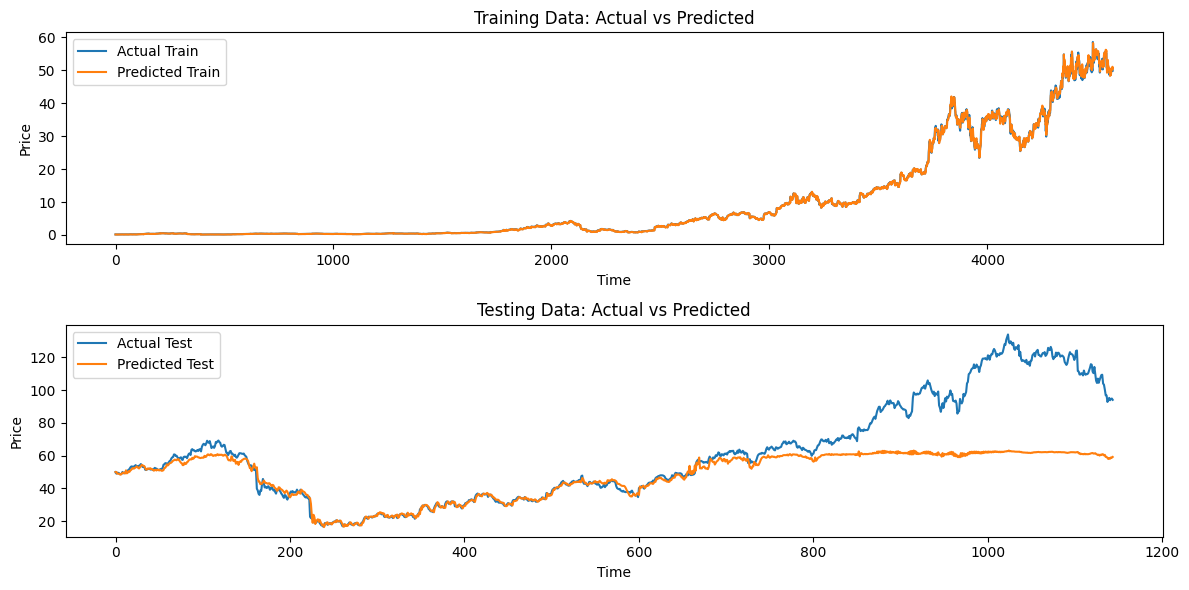

In [15]:
# Visualize the results
# This code creates a figure with two subplots to visualize the actual vs predicted closing prices for both the training and testing data. The first subplot shows the actual and predicted values for the training data, while the second subplot shows the same for the testing data. Each plot includes a title, axis labels, and a legend to differentiate between actual and predicted values. The plt.tight_layout() function is used to adjust the spacing between subplots for better visualization, and plt.show() is called to display the figure.

final_fig = plt.figure(figsize=(12, 6))
gs = final_fig.add_gridspec(2, 1)
ax1 = final_fig.add_subplot(gs[0, 0])
ax1.plot(y_train, label='Actual Train')
ax1.plot(y_train_pred, label='Predicted Train')
ax1.set_title('Training Data: Actual vs Predicted')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.legend()
ax2 = final_fig.add_subplot(gs[1, 0])
ax2.plot(y_test, label='Actual Test')
ax2.plot(y_test_pred, label='Predicted Test')
ax2.set_title('Testing Data: Actual vs Predicted')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price')
ax2.legend()
plt.tight_layout()
plt.show()